In [1]:
# Importing useful packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp

In [2]:
# Parameter
eps = 0.1

In [3]:
# ============================================================
# 1) Numerical solution of
#    eps*y'' - 2*(x^2+1)*y' + 1 = 0,  y(0)=0, y(1)=0
# ============================================================

def ode_system(x, Y, eps):
    """
    Y[0] = y
    Y[1] = y'
    """
    y = Y[0]
    yp = Y[1]
    
    # From eps*y'' - 2*(x^2+1)*y' + 1 = 0
    # => y'' = [2*(x^2+1)*y' - 1]/eps
    ypp = (2.0 * (x**2 + 1.0) * yp - 1.0) / eps
    return np.vstack((yp, ypp))


def bc(Ya, Yb):
    """
    Boundary conditions:
    y(0)=0, y(1)=0
    """
    return np.array([Ya[0], Yb[0]])


# Mesh refined near x=1 because the boundary layer is there
x_mesh = np.linspace(0.0, 1.0, 400)

# Initial guess
# A simple guess is enough, but something smooth helps
y_guess = np.zeros_like(x_mesh)
yp_guess = np.zeros_like(x_mesh)
Y_guess = np.vstack((y_guess, yp_guess))

sol = solve_bvp(
    lambda x, Y: ode_system(x, Y, eps),
    bc,
    x_mesh,
    Y_guess,
    tol=1e-8,
    max_nodes=20000
)

if sol.status != 0:
    print("Warning: solve_bvp did not fully converge.")
    print("Message:", sol.message)
else:
    print("BVP solver converged.")

BVP solver converged.


In [4]:
# Fine grid for plotting and error analysis
x = np.linspace(0.0, 1.0, 2000)
y_num = sol.sol(x)[0]

In [5]:
# ============================================================
# 2) Outer asymptotic solution
# ============================================================

def y0_outer(x):
    return 0.5 * np.arctan(x)

def y1_outer(x):
    return (1.0 / 8.0) * (1.0 / (1.0 + x**2)**2 - 1.0)

def y_outer_order1(x, eps):
    return y0_outer(x) + eps * y1_outer(x)

In [6]:
# ============================================================
# 3) Inner asymptotic solution near x=1
#    stretched variable: xi = (1-x)/eps
# ============================================================

def xi_var(x, eps):
    return (1.0 - x) / eps

def Y0_inner(xi):
    return (np.pi / 8.0) * (1.0 - np.exp(-4.0 * xi))

def Y1_inner(xi):
    return (
        -xi / 4.0
        - 3.0 / 32.0
        + np.exp(-4.0 * xi) * (
            3.0 / 32.0
            - (np.pi / 8.0) * xi
            - (np.pi / 4.0) * xi**2
        )
    )

In [7]:
# ============================================================
# 4) Composite solutions
# ============================================================

def y_comp_0(x, eps):
    """
    Leading-order composite:
    y_comp,0 = y0 + Y0 - common_part
    common_part = pi/8
    """
    xi = xi_var(x, eps)
    return y0_outer(x) - (np.pi / 8.0) * np.exp(-4.0 * xi)

def y_comp_1(x, eps):
    """
    First corrected composite:
    y_comp,1 = (y0 + eps*y1) + (Y0 + eps*Y1) - common_part_up_to_O(eps)
    
    Simplified explicit formula.
    """
    xi = xi_var(x, eps)
    return (
        0.5 * np.arctan(x)
        + (eps / 8.0) * (1.0 / (1.0 + x**2)**2 - 1.0)
        - (np.pi / 8.0) * np.exp(-4.0 * xi)
        + eps * np.exp(-4.0 * xi) * (
            3.0 / 32.0
            - (np.pi / 8.0) * xi
            - (np.pi / 4.0) * xi**2
        )
    )

In [8]:
# Evaluate asymptotic approximations
y_c0 = y_comp_0(x, eps)
y_c1 = y_comp_1(x, eps)

In [9]:
# ============================================================
# 5) Errors
# ============================================================

err_c0 = np.max(np.abs(y_num - y_c0))
err_c1 = np.max(np.abs(y_num - y_c1))

print(f"eps = {eps}")
print(f"Max error |y_num - y_comp_0| = {err_c0:.6e}")
print(f"Max error |y_num - y_comp_1| = {err_c1:.6e}")

eps = 0.1
Max error |y_num - y_comp_0| = 1.351947e-02
Max error |y_num - y_comp_1| = 5.708829e-04


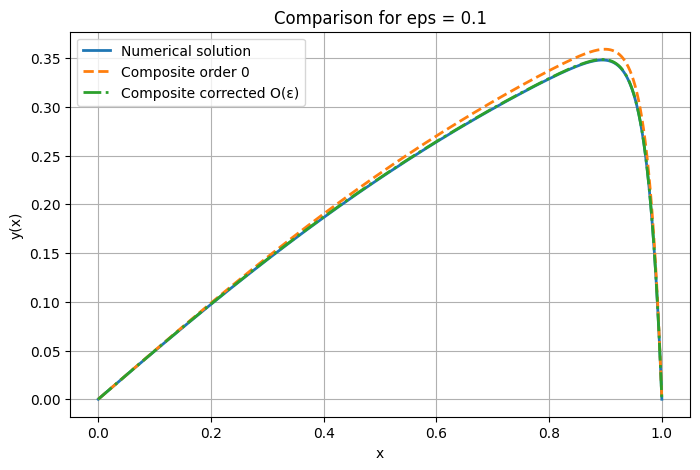

In [10]:
# ============================================================
# 6) Plot: full interval
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(x, y_num, label="Numerical solution", linewidth=2)
plt.plot(x, y_c0, "--", label="Composite order 0", linewidth=2)
plt.plot(x, y_c1, "-.", label="Composite corrected O(ε)", linewidth=2)
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title(f"Comparison for eps = {eps}")
plt.legend()
plt.grid(True)
plt.show()

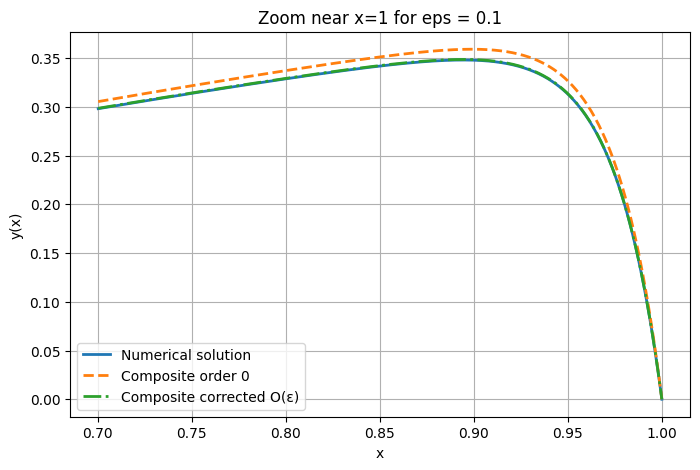

In [11]:
# ============================================================
# 7) Plot: zoom near the boundary layer x=1
# ============================================================

mask = x > 0.7

plt.figure(figsize=(8, 5))
plt.plot(x[mask], y_num[mask], label="Numerical solution", linewidth=2)
plt.plot(x[mask], y_c0[mask], "--", label="Composite order 0", linewidth=2)
plt.plot(x[mask], y_c1[mask], "-.", label="Composite corrected O(ε)", linewidth=2)
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title(f"Zoom near x=1 for eps = {eps}")
plt.legend()
plt.grid(True)
plt.show()

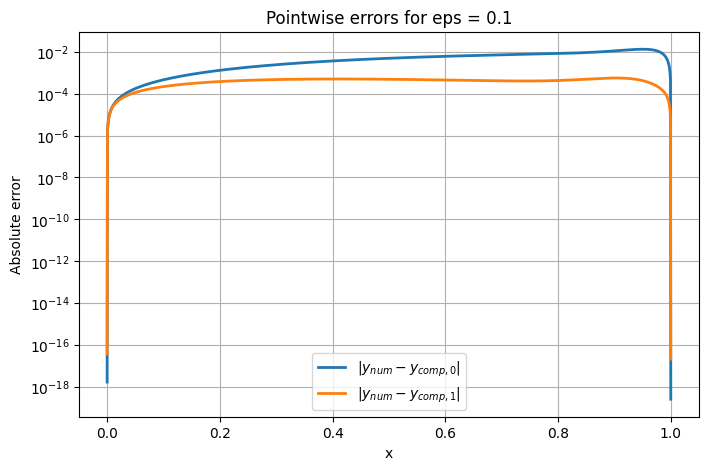

In [12]:
# ============================================================
# 8) Plot of absolute errors
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(x, np.abs(y_num - y_c0), label=r"$|y_{num} - y_{comp,0}|$", linewidth=2)
plt.plot(x, np.abs(y_num - y_c1), label=r"$|y_{num} - y_{comp,1}|$", linewidth=2)
plt.yscale("log")
plt.xlabel("x")
plt.ylabel("Absolute error")
plt.title(f"Pointwise errors for eps = {eps}")
plt.legend()
plt.grid(True, which="both")
plt.show()